# Module 2 · Lab 2.2 — LLM Robustness: Retries, Fallback & Hallucination Signals
## Retries · Exponential Backoff · Fallback · and detecting Drift & Hallucination

---

### Lab Overview

In production, LLM calls **will** fail — rate limits get hit, servers blip, networks time out — and even a *successful* call can return something **wrong**. A single unhandled error can take down a customer-facing chatbot; a single hallucinated number can mislead a claims adjuster. This lab builds the defensive patterns every GenAI engineer needs.

> **Where this sits in Module 2.** Lab 1.1 shaped a single call and Lab 2.1 composed calls into chains. **Lab 2.2 is *what breaks under load*** — and how to keep the system both **up** and **correct**.

### Two kinds of robustness

| | Keeps the service... | Failure looks like | We handle it with |
|---|---|---|---|
| **Operational robustness** | **up** | exceptions: 429, 5xx, timeouts | retries, backoff, fallback, logging |
| **Output robustness** | **correct** | a 200-OK answer that is wrong | grounding guards, faithfulness checks, determinism |




### Operational architecture


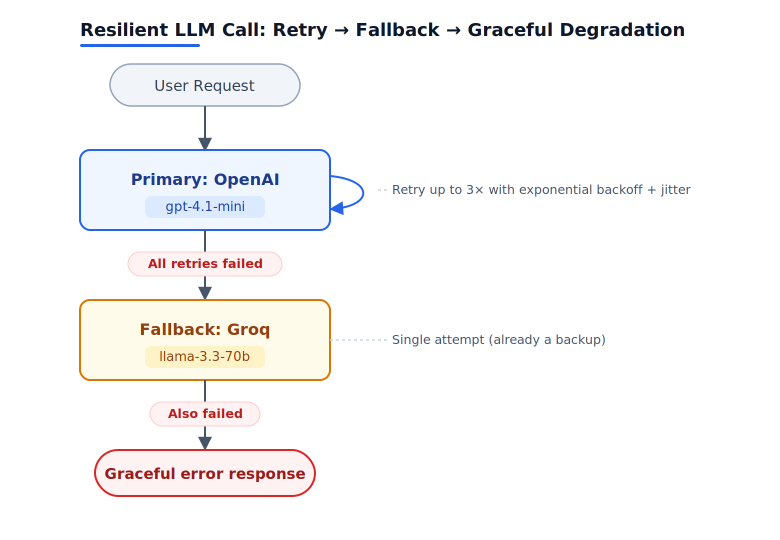

## 1. Install the SDKs

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU groq openai pandas python-dotenv langchain-core langchain-openai langchain-groq langsmith

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "groq",
    "openai",
    "pandas",
    "python-dotenv",
    "langchain-core",
    "langchain-openai",
    "langchain-groq",
    "langsmith",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

groq                       0.37.1
openai                     2.54.0
pandas                     2.3.3
python-dotenv              1.2.3
langchain-core             1.6.6
langchain-openai           1.6.6
langchain-groq             1.1.3
langsmith                  0.14.1


## 2. Load API keys — securely

The same `load_keys` helper as every lab in this workshop. The trainer supplies the OpenAI key; Groq and LangSmith keys are ones you create.

In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)

load_keys(["OPENAI_API_KEY", "GROQ_API_KEY", "LANGSMITH_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅
   GROQ_API_KEY           ✅
   LANGSMITH_API_KEY      ✅


## 3. Initialize clients & imports

We import the `openai` module itself (not just the client) because its **exception classes** — `openai.RateLimitError`, `openai.AuthenticationError`, etc. — are how we classify failures.

In [3]:
import time
import random
import logging
from datetime import datetime

import openai                      # for the exception classes
from openai import OpenAI
from groq import Groq

openai_client = OpenAI()
groq_client   = Groq()

print("Clients initialized:", "OpenAI + Groq")

Clients initialized: OpenAI + Groq


---
## 4. Task 1 — Understand the failure modes

Before writing retry logic you must know **what can go wrong**. LLM APIs fail in predictable ways, and the error *type* tells you whether retrying is worth it.

| Error | HTTP | Cause | Retry? |
|---|---|---|:--:|
| **Rate limit** | 429 | too many requests/min | ✅ wait & retry |
| **Server error** | 500 / 502 / 503 | provider infra blip | ✅ transient |
| **Timeout** | 408 / SDK | slow response or network | ✅ may succeed |
| **Authentication** | 401 / 403 | invalid/expired key | ❌ fix the key |
| **Bad request** | 400 | malformed / over context | ❌ fix the request |
| **Content filter** | 400 | blocked by safety filter | ❌ rephrase |

Let's trigger a couple of these to see the SDK's exception classes in action.

In [4]:
# Test 1: Invalid API key -> AuthenticationError (NOT retryable)
print("Test 1: Invalid API key")
print("-" * 40)
try:
    bad_client = OpenAI(api_key="sk-invalid-key-12345")
    bad_client.responses.create(model="gpt-4.1-mini", input="Hello")
except openai.AuthenticationError as error:
    print(f"Caught AuthenticationError (status {error.status_code})")
    print("   -> NOT retryable. Fix the API key.")
except Exception as error:
    print(f"Caught: {type(error).__name__}: {error}")

Test 1: Invalid API key
----------------------------------------
Caught AuthenticationError (status 401)
   -> NOT retryable. Fix the API key.


In [5]:
# Test 2: Invalid model name -> NotFoundError (NOT retryable)
print("Test 2: Invalid model name")
print("-" * 40)
try:
    openai_client.responses.create(model="gpt-nonexistent-model", input="Hello")
except openai.NotFoundError as error:
    print(f"Caught NotFoundError (status {error.status_code})")
    print("   -> NOT retryable. Check the model name.")
except Exception as error:
    print(f"Caught: {type(error).__name__}: {error}")

Test 2: Invalid model name
----------------------------------------
Caught NotFoundError (status 404)
   -> NOT retryable. Check the model name.


In [6]:
# Test 3: A successful call (baseline)
print("Test 3: Successful call (baseline)")
print("-" * 40)
try:
    response = openai_client.responses.create(
        model="gpt-4.1-mini", input="Say 'API is working' in exactly 3 words.", max_output_tokens=20)
    print("Success:", response.output_text)
except Exception as error:
    print(f"Unexpected error: {type(error).__name__}: {error}")

Test 3: Successful call (baseline)
----------------------------------------
Success: API is working.


### 📝 Key takeaway
The pivotal design decision is **which errors are retryable**. Rate limits (429) and server errors (5xx) are transient — a short wait often fixes them. Auth and bad-request errors are permanent — retrying just wastes time and money.

---
## 5. Task 2 — Retry with exponential backoff

**Business scenario — insurance claims pipeline.** An insurer pushes 500+ claims/hour through an LLM summarizer. At peak, rate limits fire constantly. The pipeline must **auto-retry** without dropping claims or hammering the API.

**Exponential backoff** waits progressively longer between attempts (≈1s → 2s → 4s) instead of retrying instantly (which floods the API harder). **Jitter** adds a small random offset so many workers don't all retry on the same tick — the *thundering-herd* problem.

In [7]:
# Classify errors once, reuse everywhere.
RETRYABLE_ERRORS = (
    openai.RateLimitError,       # 429 — too many requests
    openai.APITimeoutError,      # request timed out
    openai.InternalServerError,  # 500 — server-side issue
    openai.APIConnectionError,   # network connectivity problem
)
NON_RETRYABLE_ERRORS = (
    openai.AuthenticationError,  # 401/403 — bad key
    openai.BadRequestError,      # 400 — invalid input
    openai.NotFoundError,        # 404 — wrong model name
)

def call_openai_with_retry(system_prompt, user_prompt, model="gpt-4.1-mini",
                           temperature=0.7, max_tokens=500,
                           max_retries=3, base_delay=1.0):
    """Call OpenAI's Responses API with exponential-backoff retries.

    Retries on: rate limit, timeout, server error, connection error.
    Fails fast on: auth error, bad request, not found.
    Backoff: delay = base_delay * (2 ** attempt) + random jitter.
    """
    for attempt in range(max_retries + 1):       # attempt 0 == first try
        try:
            start = time.time()
            response = openai_client.responses.create(
                model=model, instructions=system_prompt, input=user_prompt,
                temperature=temperature, max_output_tokens=max_tokens)
            return {
                "provider": "OpenAI", "model": model,
                "response": response.output_text,
                "latency_sec": round(time.time() - start, 2),
                "attempts": attempt + 1, "status": "success",
            }
        except NON_RETRYABLE_ERRORS as error:
            print(f"  ❌ Non-retryable: {type(error).__name__} — failing fast (no retries)")
            raise
        except RETRYABLE_ERRORS as error:
            if attempt < max_retries:
                delay = base_delay * (2 ** attempt) + random.uniform(0, 0.5)
                print(f"  ⚠️ Attempt {attempt + 1} failed ({type(error).__name__}); "
                      f"retrying in {delay:.1f}s ({max_retries - attempt} left)")
                time.sleep(delay)
            else:
                print(f"  ❌ All {max_retries + 1} attempts exhausted: {type(error).__name__}")
                raise
        except Exception as error:
            print(f"  ❌ Unexpected: {type(error).__name__}: {error}")
            raise

print("Retry function defined.")

Retry function defined.


In [8]:
# Happy-path test: auto-summarize a health-insurance claim
system = "You are an insurance claims analyst. Summarize claims concisely."
claim = """Claim #HC-2025-4412: Policyholder Meera Shah, age 45, was admitted for
emergency appendectomy at Apollo Hospital, Mumbai on Feb 3, 2025. Total bill: ₹3.2L.
Policy: Star Health Comprehensive, Sum Insured ₹10L, no sub-limits on surgery.
Pre-authorization obtained. Discharged on Feb 5. All documents submitted."""

result = call_openai_with_retry(system, claim, max_tokens=200)
print(f"\n✅ Success in {result['attempts']} attempt(s) | {result['latency_sec']}s\n")
print(result["response"])


✅ Success in 1 attempt(s) | 1.5s

Claim #HC-2025-4412 Summary:  
Policyholder Meera Shah (45) underwent emergency appendectomy at Apollo Hospital, Mumbai from Feb 3-5, 2025. Total bill ₹3.2L under Star Health Comprehensive policy with ₹10L sum insured and no surgery sub-limits. Pre-authorization obtained and all documents submitted.


In [9]:
# Prove non-retryable errors fail IMMEDIATELY (no wasted retries).
# Teaching trick: temporarily swap in a broken client via globals(), then restore it.
print("Non-retryable error should fail immediately...")
print("-" * 60)
real_client = openai_client
try:
    globals()["openai_client"] = OpenAI(api_key="sk-broken-key")
    call_openai_with_retry("test", "test", max_retries=3)
except openai.AuthenticationError:
    print("\n✅ Failed immediately — zero retries wasted on a permanent error")
except Exception as error:
    print(f"\nCaught: {type(error).__name__}")
finally:
    globals()["openai_client"] = real_client       # always restore
    print("Real client restored.")

Non-retryable error should fail immediately...
------------------------------------------------------------
  ❌ Non-retryable: AuthenticationError — failing fast (no retries)

✅ Failed immediately — zero retries wasted on a permanent error
Real client restored.


### 📝 Discussion
- **Backoff** prevents all clients from retrying on the same instant (thundering herd).
- **Jitter** de-synchronizes retries across pipeline workers.
- **Fail-fast on permanent errors** saves time and money — no point retrying a bad key 3×.

---
## 6. Task 3 — Fallback provider (OpenAI → Groq)

**Business scenario — real-time banking chatbot.** A bank's bot handles 10,000+ chats/day. If OpenAI is down or throttled, the bot must **not** go dark — it silently switches to Groq (Qwen3.8 27B) so customers never notice.

This is the **1-level fallback**: Primary (with retries) → Fallback (single try) → graceful error. Note we **don't** fall back on non-retryable errors — if our request is malformed, a second provider won't help.

In [10]:
def call_groq_fallback(system_prompt, user_prompt, temperature=0.7, max_tokens=500):
    """Fallback provider: Groq Cloud running Qwen3.8 27B."""
    start = time.time()
    response = groq_client.chat.completions.create(
        model="qwen/qwen3.8-27b",
        messages=[{"role": "system", "content": system_prompt},
                  {"role": "user", "content": user_prompt}],
        temperature=temperature, max_tokens=max_tokens)
    return {
        "provider": "Groq (Fallback)", "model": "qwen/qwen3.8-27b",
        "response": response.choices[0].message.content,
        "latency_sec": round(time.time() - start, 2), "status": "success_via_fallback",
    }

def call_with_fallback(system_prompt, user_prompt, temperature=0.7, max_tokens=500):
    """Primary (OpenAI + retries) -> Fallback (Groq once) -> graceful error."""
    try:
        print("🔵 Trying primary: OpenAI (gpt-4.1-mini)...")
        result = call_openai_with_retry(system_prompt, user_prompt,
                                        temperature=temperature, max_tokens=max_tokens)
        print(f"   ✅ Primary succeeded in {result['attempts']} attempt(s)")
        return result
    except NON_RETRYABLE_ERRORS as error:
        print(f"   ❌ Non-retryable — skipping fallback: {type(error).__name__}")
        return {"provider": "None", "model": "N/A",
                "response": f"Error: {type(error).__name__} — {str(error)[:200]}",
                "latency_sec": -1, "status": "permanent_error"}
    except Exception as primary_error:
        print("\n🟡 Primary failed after retries. Switching to fallback: Groq (Qwen3.8 27B)...")
        try:
            result = call_groq_fallback(system_prompt, user_prompt,
                                        temperature=temperature, max_tokens=max_tokens)
            print(f"   ✅ Fallback succeeded | {result['latency_sec']}s")
            return result
        except Exception as fallback_error:
            print(f"   ❌ Fallback also failed: {type(fallback_error).__name__}")
            return {"provider": "None", "model": "N/A",
                    "response": "Service temporarily unavailable. Please try again later.",
                    "latency_sec": -1, "status": "all_providers_failed",
                    "primary_error": str(primary_error)[:200],
                    "fallback_error": str(fallback_error)[:200]}

print("Fallback functions defined.")

Fallback functions defined.


In [11]:
# Test 1 — happy path (primary succeeds)
print("=" * 60); print("Test 1: Primary succeeds (happy path)"); print("=" * 60)
result = call_with_fallback("You are a helpful retail banking assistant. Be concise.",
                            "What documents do I need to open a salary account?", max_tokens=200)
print(f"\nProvider: {result['provider']} | Status: {result['status']}\n")
print(result["response"])

Test 1: Primary succeeds (happy path)
🔵 Trying primary: OpenAI (gpt-4.1-mini)...
   ✅ Primary succeeded in 1 attempt(s)

Provider: OpenAI | Status: success

To open a salary account, you typically need:

1. Proof of Identity (e.g., Aadhaar card, PAN card, passport, voter ID)
2. Proof of Address (e.g., utility bill, rental agreement, Aadhaar card)
3. Recent Passport-sized Photographs
4. Employment Proof or Salary Certificate from your employer
5. PAN Card (for tax purposes)

Requirements may vary slightly by bank.


In [12]:
# Test 2 — force primary outage, watch the fallback take over
print("=" * 60); print("Test 2: Primary fails -> Groq fallback handles it"); print("=" * 60)
real_client = openai_client
globals()["openai_client"] = OpenAI(api_key="sk-broken-for-testing")
try:
    result = call_with_fallback("You are a helpful banking assistant. Be concise.",
                                "How do I set up auto-pay for my credit-card bill?", max_tokens=200)
    print(f"\nProvider: {result['provider']} | Status: {result['status']}\n")
    print(result["response"])
finally:
    globals()["openai_client"] = real_client
    print("\nReal client restored.")

Test 2: Primary fails -> Groq fallback handles it
🔵 Trying primary: OpenAI (gpt-4.1-mini)...
  ❌ Non-retryable: AuthenticationError — failing fast (no retries)
   ❌ Non-retryable — skipping fallback: AuthenticationError

Provider: None | Status: permanent_error

Error: AuthenticationError — Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-broke*********ting. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error'

Real client restored.


### 📝 Discussion
- The end-user never sees the switch — the response shape is identical.
- Groq's Qwen3.8 27B has a *different* quality profile, but a live answer beats an outage.
- Always **log which provider served each request** for quality and cost monitoring (next).

---
## 7. Task 4 — Production-grade caller with logging

**Business scenario — e-commerce review summarizer.** Thousands of reviews/day flow through one pipeline. It must be bulletproof: retries + fallback + **structured logging** + timing + a `request_id` for tracing. We fold everything into one reusable function.

In [13]:
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)-7s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("llm_robustness")

def robust_llm_call(system_prompt, user_prompt, temperature=0.7, max_tokens=500,
                    max_retries=3, base_delay=1.0, request_id=None):
    """Production caller: backoff retries + OpenAI->Groq fallback + logging + tracing."""
    resolved_request_id = request_id or f"req-{int(time.time())}"
    call_log = {"request_id": resolved_request_id, "start_time": datetime.now().isoformat(),
                "primary_attempts": 0, "used_fallback": False}

    # --- Primary: OpenAI with retries ---
    for attempt in range(max_retries + 1):
        call_log["primary_attempts"] = attempt + 1
        try:
            logger.info(f"[{resolved_request_id}] Primary attempt {attempt + 1}/{max_retries + 1}")
            start = time.time()
            response = openai_client.responses.create(
                model="gpt-4.1-mini", instructions=system_prompt, input=user_prompt,
                temperature=temperature, max_output_tokens=max_tokens)
            latency = round(time.time() - start, 2)
            logger.info(f"[{resolved_request_id}] ✅ Primary succeeded | {latency}s")
            call_log.update({"provider": "OpenAI", "model": "gpt-4.1-mini",
                             "response": response.output_text, "latency_sec": latency,
                             "status": "success",
                             "input_tokens": response.usage.input_tokens,
                             "output_tokens": response.usage.output_tokens})
            return call_log
        except NON_RETRYABLE_ERRORS as error:
            logger.error(f"[{resolved_request_id}] Non-retryable: {type(error).__name__}")
            call_log.update({"provider": "None", "response": f"Error: {error}",
                             "status": "permanent_error", "error_type": type(error).__name__})
            return call_log
        except RETRYABLE_ERRORS as error:
            if attempt < max_retries:
                delay = base_delay * (2 ** attempt) + random.uniform(0, 0.5)
                logger.warning(f"[{resolved_request_id}] {type(error).__name__} — retry in {delay:.1f}s")
                time.sleep(delay)
            else:
                logger.error(f"[{resolved_request_id}] Primary exhausted after {max_retries + 1} attempts")
        except Exception as error:
            logger.error(f"[{resolved_request_id}] Unexpected: {type(error).__name__}: {str(error)[:100]}")
            if attempt == max_retries:
                break

    # --- Fallback: Groq ---
    call_log["used_fallback"] = True
    logger.info(f"[{resolved_request_id}] 🔄 Switching to fallback: Groq (Qwen3.8 27B)")
    try:
        start = time.time()
        response = groq_client.chat.completions.create(
            model="qwen/qwen3.8-27b",
            messages=[{"role": "system", "content": system_prompt},
                      {"role": "user", "content": user_prompt}],
            temperature=temperature, max_tokens=max_tokens)
        latency = round(time.time() - start, 2)
        logger.info(f"[{resolved_request_id}] ✅ Fallback succeeded | {latency}s")
        call_log.update({"provider": "Groq (Fallback)", "model": "qwen/qwen3.8-27b",
                         "response": response.choices[0].message.content, "latency_sec": latency,
                         "status": "success_via_fallback",
                         "input_tokens": response.usage.prompt_tokens,
                         "output_tokens": response.usage.completion_tokens})
        return call_log
    except Exception as error:
        logger.critical(f"[{resolved_request_id}] ❌ Both providers failed!")
        call_log.update({"provider": "None", "model": "N/A",
                         "response": "Service temporarily unavailable. Please try again later.",
                         "latency_sec": -1, "status": "all_providers_failed", "error": str(error)[:200]})
        return call_log

print("Production robust caller defined.")

Production robust caller defined.


---
## 7b. The same reliability, expressed in LangChain ⭐

Tasks 2–4 built retry and fallback by hand, around raw provider SDKs. In LangChain every chain is a
**Runnable**, and any Runnable can wear the same armour with two method calls — no loops, no sleeps:

| Concern | By hand (Tasks 2–4) | Chain-level (LangChain) |
|---|---|---|
| Retry transient errors with backoff | `call_openai_with_retry()` — a loop, a sleep, two exception tuples | `.with_retry(retry_if_exception_type=RETRYABLE_ERRORS, wait_exponential_jitter=True, stop_after_attempt=3)` |
| Fail fast on permanent errors | `NON_RETRYABLE_ERRORS` → raise at once | only the listed exception types are retried; anything else raises at once |
| Fall back to another provider | `call_with_fallback()` — try/except, then Groq | `.with_fallbacks([fallback_chain])` |
| Know what happened | a logger and a `request_id` (Task 4) | a **LangSmith trace** of every step — switched on below |

The error classes you wrote in Task 2 plug straight in: the idea carries over, only the plumbing
disappears.

In [14]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

claim_summary_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an insurance claims analyst. Summarize claims concisely."),
    ("human", "{claim_text}"),
])

# max_retries=0 switches off the OpenAI client's own silent retries, so the chain-level
# .with_retry() below is the only retry policy in play — and its behaviour is what you see.
primary_model = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2, max_retries=0)
fallback_model = ChatGroq(model="qwen/qwen3.8-27b", temperature=0.2)

primary_chain = claim_summary_prompt | primary_model | StrOutputParser()
fallback_chain = claim_summary_prompt | fallback_model | StrOutputParser()

resilient_chain = primary_chain.with_retry(
    retry_if_exception_type=RETRYABLE_ERRORS,   # Task 2's transient errors — nothing else
    wait_exponential_jitter=True,
    stop_after_attempt=3,
).with_fallbacks([fallback_chain])

print(resilient_chain.invoke({"claim_text": claim}))

08:21:03 | INFO    | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Claim #HC-2025-4412: Meera Shah (45) underwent emergency appendectomy at Apollo Hospital, Mumbai on Feb 3, 2025. Total bill ₹3.2L under Star Health Comprehensive policy (₹10L sum insured, no surgery sub-limits). Pre-authorization obtained; discharged Feb 5. All documents submitted.


### Prove the failover — a primary that can never answer

Point the primary at a model that does not exist. That is a **permanent** error (404), so
`.with_retry()` does not retry it — and `.with_fallbacks()` hands the request to Groq at once.

In [15]:
broken_primary_chain = (claim_summary_prompt
                        | ChatOpenAI(model="gpt-nonexistent-model", max_retries=0)
                        | StrOutputParser())
failover_chain = broken_primary_chain.with_retry(
    retry_if_exception_type=RETRYABLE_ERRORS, wait_exponential_jitter=True, stop_after_attempt=3,
).with_fallbacks([fallback_chain])

started_at = time.time()
failover_answer = failover_chain.invoke({"claim_text": claim})
print(f"Answered in {time.time() - started_at:.1f}s. A 404 is permanent, so it was not retried —")
print("the fallback (Groq) answered straight away:\n")
print(failover_answer)

08:21:03 | INFO    | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 404 Not Found"
08:21:04 | INFO    | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Answered in 1.5s. A 404 is permanent, so it was not retried —
the fallback (Groq) answered straight away:

**Claim Summary: HC-2025-4412**

*   **Policyholder:** Meera Shah (Age 45)
*   **Policy:** Star Health Comprehensive (Sum Insured: ₹10L)
*   **Incident:** Emergency appendectomy at Apollo Hospital, Mumbai.
*   **Timeline:** Admitted Feb 3, 2025; Discharged Feb 5, 2025.
*   **Financials:** Total Bill ₹3.2L.
*   **Status:** Pre-authorization obtained; all documents submitted.
*   **Assessment:** Claim appears valid and fully covered under policy terms (no sub-limits on surgery).


### Switch on LangSmith — and prove it is on

Two environment variables switch LangSmith tracing on for every LangChain call in the process. The
catch that costs teams days: LangSmith reads them **once**, on the first LangChain call, and caches
the answer. This notebook has already run chains above with tracing off, so setting the variables
now would be silently ignored. The cell below clears that cache, then **asserts** that tracing is
live — a valid API key proves only that LangSmith is reachable, not that anything is being recorded.

> Only **LangChain** calls are traced this way. The raw-SDK calls in Tasks 1–4 are not — itself an
> argument for routing production calls through one instrumented layer.

In [16]:
import langsmith

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "workshop-lab-2-2"

# LangSmith caches both settings on the first LangChain call. The chains above already ran with
# tracing off, so clear the cache — without these two lines the settings above are silently ignored.
langsmith.utils.get_env_var.cache_clear()
langsmith.utils.get_tracer_project.cache_clear()

langsmith_client = langsmith.Client()
list(langsmith_client.list_projects(limit=1))   # a bad or missing key stops here, loudly

tracing_is_live = langsmith.utils.tracing_is_enabled()
resolved_project = langsmith.utils.get_tracer_project()
print(f"tracing enabled : {tracing_is_live}")
print(f"target project  : {resolved_project!r}")
assert tracing_is_live is True, "tracing is off — the env-var cache was not cleared"
assert resolved_project == os.environ["LANGSMITH_PROJECT"], "traces would land in the wrong project"

tracing enabled : True
target project  : 'workshop-lab-2-2'


In [17]:
from langchain_core.tracers.context import collect_runs
from langchain_core.tracers.langchain import wait_for_all_tracers

# collect_runs() captures the same run tree that is being sent to LangSmith, so you can read it
# right here as well as in the LangSmith UI.
with collect_runs() as run_collector:
    traced_answer = failover_chain.invoke(
        {"claim_text": claim},
        config={"tags": ["lab-2.2-failover"], "metadata": {"lab": "2.2"}},
    )
wait_for_all_tracers()   # block until the batched trace has actually been sent to LangSmith


def step_tokens(traced_run):
    """Return the total tokens a model step reported, or None for a step that calls no model."""
    if traced_run.run_type != "llm" or not traced_run.outputs:
        return None
    generations = traced_run.outputs.get("generations") or []
    if not generations or not generations[0]:
        return None
    message_fields = generations[0][0].get("message", {}).get("kwargs", {})
    usage = message_fields.get("usage_metadata") or {}
    return usage.get("total_tokens")


def print_run_tree(traced_run, depth=0):
    """Print one step of the trace — name, type, status, time, tokens — then its children."""
    step_seconds = (traced_run.end_time - traced_run.start_time).total_seconds()
    step_status = "error" if traced_run.error else "ok"
    tokens = step_tokens(traced_run)
    step_label = f"{'  ' * depth}{traced_run.name}"
    token_text = tokens if tokens is not None else ""
    print(f"{step_label:<36} {traced_run.run_type:<8} {step_status:<6} "
          f"{step_seconds:6.2f}s  {token_text:>6}")
    for child_run in traced_run.child_runs:
        print_run_tree(child_run, depth + 1)


print(f"{'step':<36} {'type':<8} {'status':<6} {'time':>7}  {'tokens':>6}")
print_run_tree(run_collector.traced_runs[0])
print(f"\nThe same trace is in LangSmith: smith.langchain.com → Projects → "
      f"{os.environ['LANGSMITH_PROJECT']}")

08:21:08 | INFO    | HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 404 Not Found"
08:21:09 | INFO    | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


step                                 type     status    time  tokens
RunnableWithFallbacks                chain    ok       0.97s        
  RunnableSequence                   chain    error    0.55s        
    RunnableSequence                 chain    error    0.54s        
      ChatPromptTemplate             prompt   ok       0.13s        
      ChatOpenAI                     llm      error    0.40s        
  RunnableSequence                   chain    ok       0.41s        
    ChatPromptTemplate               prompt   ok       0.00s        
    ChatGroq                         llm      ok       0.41s     276
    StrOutputParser                  parser   ok       0.00s        

The same trace is in LangSmith: smith.langchain.com → Projects → workshop-lab-2-2


### Reading the run tree — what to look for

- **Which step failed, and was it retried?** The root `RunnableWithFallbacks` has two branches. The
  first is the primary chain wearing `.with_retry()` — the retry wrapper takes the name of the chain
  it wraps, so it shows as an outer `RunnableSequence` around the real one. Inside, the `ChatOpenAI`
  call to `gpt-nonexistent-model` shows `error` and appears **once**: a 404 is permanent, so
  `.with_retry()` let it straight through instead of wasting attempts.
- **Which fallback answered?** The second branch — the one with `ChatGroq` — is marked `ok`: the
  customer got an answer, and the trace records who gave it.
- **Where did the time go?** Read the time column: the failed attempt and the fallback call are the
  whole cost of this request.
- **Tokens and cost.** The tokens column shows what the answering model used. Open the same trace at
  **smith.langchain.com → Projects → workshop-lab-2-2** for every step's latency and tokens, and
  the cost of priced models.

`collect_runs()` gives you the run tree in code — useful in tests. LangSmith keeps it, searchable, for
every run. From here on every LangChain call in this kernel is traced: when something is slow or
wrong, the trace answers *"which step?"* before you have to guess.

---
## 8. Task 5 — End-to-end tests across industries

Run the production caller through several domains — healthcare, e-commerce, and a batch of insurance claims.

In [18]:
# Scenario 1: Healthcare — ED triage summary
print("=" * 60); print("Scenario 1: Healthcare — Patient Triage Summary"); print("=" * 60)
result = robust_llm_call(
    system_prompt="You are an emergency-department triage assistant. Summarize for the attending physician.",
    user_prompt="""Patient: Male, 55, chest pain radiating to left arm for 2 hours.
History: Type 2 diabetes (10 yrs), hypertension, ex-smoker (quit 2 yrs ago).
Vitals: BP 165/95, HR 102, SpO2 96%, afebrile. ECG: ST elevation in leads II, III, aVF.
Troponin pending. Aspirin 325mg and nitro sublingual given.""",
    max_tokens=200, request_id="triage-001")
print(f"\nProvider: {result['provider']} | Status: {result['status']}")
print(f"Attempts: {result['primary_attempts']} | Fallback used: {result['used_fallback']}\n")
print(result["response"])

08:21:17 | INFO    | [triage-001] Primary attempt 1/4


Scenario 1: Healthcare — Patient Triage Summary


08:21:19 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
08:21:19 | INFO    | [triage-001] ✅ Primary succeeded | 2.08s



Provider: OpenAI | Status: success
Attempts: 1 | Fallback used: False

55-year-old male presenting with 2 hours of chest pain radiating to left arm. Past medical history includes type 2 diabetes (10 years), hypertension, and ex-smoker (quit 2 years ago). Vitals show BP 165/95, HR 102, SpO2 96%, afebrile. ECG reveals ST elevation in leads II, III, and aVF, consistent with an acute inferior STEMI. Troponin results are pending. Initial treatment with aspirin 325mg and sublingual nitroglycerin administered. Patient requires urgent cardiology evaluation for possible reperfusion therapy.


In [19]:
# Scenario 2: E-commerce — product-review summary
print("=" * 60); print("Scenario 2: E-Commerce — Product Review Summary"); print("=" * 60)
result = robust_llm_call(
    system_prompt="Summarize customer reviews into key pros, cons, and a verdict in 2-3 sentences.",
    user_prompt="""Reviews for Samsung Galaxy S25 Ultra (500+ reviews aggregated):
- Camera is phenomenal, especially night mode and the 200MP sensor
- Battery lasts a full day under heavy use; 65% charge in 30 min
- S-Pen integration is seamless for note-taking
- Phone is heavy (233g) and slippery without a case
- Price ₹1.3L feels overpriced to many reviewers
- One UI ships with too many pre-installed Samsung apps""",
    max_tokens=150, request_id="review-042")
print(f"\nProvider: {result['provider']} | Status: {result['status']}\n")
print(result["response"])

08:21:19 | INFO    | [review-042] Primary attempt 1/4


Scenario 2: E-Commerce — Product Review Summary


08:21:21 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
08:21:21 | INFO    | [review-042] ✅ Primary succeeded | 1.85s



Provider: OpenAI | Status: success

Key pros of the Samsung Galaxy S25 Ultra include its phenomenal camera performance with a standout 200MP sensor and excellent night mode, long-lasting battery that charges quickly, and seamless S-Pen integration for productivity. On the downside, users find the phone heavy and slippery without a case, the price steep at ₹1.3 lakh, and One UI cluttered with excessive pre-installed Samsung apps. Overall, the S25 Ultra is a powerhouse flagship ideal for photography and productivity enthusiasts but may feel costly and cumbersome to some.


In [20]:
# Scenario 3: Batch — 5 insurance claims
print("=" * 60); print("Scenario 3: Batch Processing — Insurance Claim Assessments"); print("=" * 60)
claims = [
    "Claim #A101: Vehicle rear-ended at signal. Bumper + taillight damage. Estimate ₹45,000.",
    "Claim #A102: Water damage to apartment from upstairs pipe burst. Flooring + walls. Estimate ₹2.8L.",
    "Claim #A103: Laptop stolen from checked baggage on Delhi-Mumbai flight. ₹1.2L, 8 months old.",
    "Claim #A104: Dengue hospitalization, 5 days at Max Hospital. Bill ₹1.1L. Cashless claim.",
    "Claim #A105: Shop fire from electrical short. Inventory + fixtures destroyed. Estimate ₹12L.",
]
system = ("You are an insurance claims processor. Give a 1-line assessment: "
          "LIKELY COVERED / UNLIKELY / NEEDS REVIEW — and the key factor.")

batch_results = []
for claim_index, claim in enumerate(claims):
    print(f"\nProcessing claim {claim_index + 1}/5...")
    batch_results.append(robust_llm_call(system, claim, max_tokens=80, request_id=f"batch-{claim_index + 1}"))
    time.sleep(0.3)   # gentle pacing to respect rate limits

print("\n" + "=" * 60); print("BATCH RESULTS SUMMARY"); print("=" * 60)
for claim_index, result in enumerate(batch_results):
    print(f"\n{claims[claim_index].split(':')[0]} | {result['provider']} | {result['latency_sec']}s")
    print(f"  -> {result['response'][:150]}")

08:21:21 | INFO    | [batch-1] Primary attempt 1/4


Scenario 3: Batch Processing — Insurance Claim Assessments

Processing claim 1/5...


08:21:22 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
08:21:22 | INFO    | [batch-1] ✅ Primary succeeded | 1.06s
08:21:22 | INFO    | [batch-2] Primary attempt 1/4



Processing claim 2/5...


08:21:24 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
08:21:24 | INFO    | [batch-2] ✅ Primary succeeded | 1.26s
08:21:24 | INFO    | [batch-3] Primary attempt 1/4


...


Processing claim 4/5...


08:21:28 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
08:21:28 | INFO    | [batch-4] ✅ Primary succeeded | 1.62s
08:21:28 | INFO    | [batch-5] Primary attempt 1/4



Processing claim 5/5...


08:21:30 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"
08:21:30 | INFO    | [batch-5] ✅ Primary succeeded | 1.91s



BATCH RESULTS SUMMARY

Claim #A101 | OpenAI | 1.06s
  -> LIKELY COVERED – Rear-end collision causing bumper and taillight damage is typically covered under standard auto insurance policies.

Claim #A102 | OpenAI | 1.26s
  -> LIKELY COVERED — Water damage from a sudden pipe burst is typically covered under standard homeowner’s insurance policies.

Claim #A103 | OpenAI | 1.88s
  -> NEEDS REVIEW — Theft from checked baggage on a domestic flight may have airline liability limits and policy exclusions; verify coverage terms.

Claim #A104 | OpenAI | 1.62s
  -> LIKELY COVERED – Hospitalization for dengue is typically covered under standard health insurance policies.

Claim #A105 | OpenAI | 1.91s
  -> LIKELY COVERED — Fire damage from electrical short is typically covered under standard commercial property insurance.


---
## 9. Task 6 — Reliability metrics dashboard

**Business scenario — ops monitoring.** You need visibility into how often calls succeed, fail, or use the fallback. This data drives provider selection and SLA conversations.

In [21]:
import pandas as pd

def compute_reliability_metrics(results):
    """Reliability metrics from a batch of robust_llm_call results."""
    total = len(results)
    if total == 0:
        return {}
    success_primary  = sum(1 for result in results if result["status"] == "success")
    success_fallback = sum(1 for result in results if result["status"] == "success_via_fallback")
    failed           = sum(1 for result in results if result["status"] in ("permanent_error", "all_providers_failed"))
    latencies = [result["latency_sec"] for result in results if result["latency_sec"] > 0]
    average_latency  = round(sum(latencies) / len(latencies), 2) if latencies else 0
    average_attempts = round(sum(result.get("primary_attempts", 1) for result in results) / total, 1)
    return {
        "total_requests":       total,
        "success_primary":      success_primary,
        "success_fallback":     success_fallback,
        "success_rate":         f"{(success_primary + success_fallback) / total * 100:.1f}%",
        "failed":               failed,
        "avg_latency_sec":      average_latency,
        "avg_primary_attempts": average_attempts,
        "fallback_usage":       f"{success_fallback / total * 100:.1f}%",
    }

metrics = compute_reliability_metrics(batch_results)
print("📊 RELIABILITY METRICS")
print(pd.Series(metrics).to_frame("value").to_string())

📊 RELIABILITY METRICS
                       value
total_requests             5
success_primary            5
success_fallback           0
success_rate          100.0%
failed                     0
avg_latency_sec         1.55
avg_primary_attempts     1.0
fallback_usage          0.0%


### 📝 What to monitor in production

| Metric | Tells you | Alert threshold |
|---|---|---|
| **Success rate** | overall health | < 99% |
| **Fallback usage** | primary reliability | > 5% |
| **Avg retries / request** | transient-error frequency | > 1.5 |
| **P95 latency** | tail latency hurting UX | > 5s |
| **Error-type mix** | root-cause patterns | review weekly |

---
## 10. Task 7 — Output robustness: drift, hallucination & sensitivity ⭐ *(new)*

Everything above keeps the service **up**. But a call can return **200 OK and still be wrong**. Output robustness is about keeping answers **correct** — critical in finance, healthcare, and insurance where a confident-but-false answer is worse than an outage.

We'll look at three failure modes and a guard for each:
1. **Hallucination** — inventing facts (especially on a false premise)
2. **Unfaithful figures** — emitting numbers that aren't in the source
3. **Prompt sensitivity / drift** — different answers to the same question

### 10a · Hallucination on a false premise 🏦

We ask about a regulation that **does not exist**. A naive prompt may "play along" and fabricate details; a **grounding guard** instructs the model to refuse what it can't verify.

In [22]:
FALSE_PREMISE = ("Summarize the key points of the RBI's 2027 nationwide ban on all UPI "
                 "payments above ₹50,000.")

print("🔴 NAIVE (no guard):")
naive = openai_client.responses.create(model="gpt-4.1-mini", input=FALSE_PREMISE, max_output_tokens=180)
print(naive.output_text)

print("\n🟢 GROUNDED (with guard):")
GUARD = ("Answer only from well-established facts. If the question assumes an event, rule, or "
         "regulation you cannot verify, reply exactly: \"I can't verify that this is real.\" and say "
         "briefly why. Never invent specifics.")
grounded = openai_client.responses.create(model="gpt-4.1-mini", instructions=GUARD,
                                          input=FALSE_PREMISE, max_output_tokens=180)
print(grounded.output_text)

🔴 NAIVE (no guard):


08:21:33 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


Here are the key points of the RBI's 2027 nationwide ban on all UPI payments above ₹50,000:

- **Effective Date:** The ban will be implemented starting in the year 2027.
- **Scope:** All Unified Payments Interface (UPI) transactions exceeding ₹50,000 will be prohibited.
- **Purpose:** Designed to curb large-value digital transactions via UPI, likely to enhance security, control risks, and encourage alternative payment methods for high-value transfers.
- **Impact:** Users will need to use other payment channels such as NEFT, RTGS, or wire transfers for amounts above ₹50,000.
- **Rationale:** The move may be aimed at reducing fraud, ensuring better monitoring of large transactions, and maintaining financial stability.

Let me know if you want more details or specific insights!

🟢 GROUNDED (with guard):


08:21:34 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


I can't verify that this is real. There is no credible information or official announcement from the Reserve Bank of India (RBI) concerning a nationwide ban on all UPI payments above ₹50,000 in 2027.


> Models increasingly push back even without a guard — but you can't *rely* on that. The grounding instruction turns "usually safe" into "reliably safe." (Robust detection at scale is what **guardrails** formalize — you meet input and output guardrails in Module 8.)

### 10b · Faithfulness check — did the model invent a number? 📄

For summarization in regulated domains, the cheapest safety net is a **programmatic check**: every monetary figure in the summary should also appear in the source. Anything extra is a red flag.

In [23]:
import re

SOURCE = ("Claim #HC-2025-4412: Total bill ₹3.2L. Sum Insured ₹10L. "
          "Pre-authorization obtained. Co-pay 10%.")

output = call_openai_with_retry(
    "Summarize the claim in 2 sentences. Use ONLY figures that appear verbatim in the source text.",
    SOURCE, temperature=0, max_tokens=120)
summary = output["response"]
print("Summary:\n", summary, "\n")

def money_figures(text):
    """Extract money-like tokens, e.g. ₹3.2L, ₹10L, ₹45,000, and 10%."""
    return {match.replace(" ", "") for match in re.findall(r"₹\s*[\d.,]+\s*[LKlk]?|\d+\s*%", text)}

source_figures, output_figures = money_figures(SOURCE), money_figures(summary)
unsupported = output_figures - source_figures
print("Figures in source :", source_figures)
print("Figures in summary:", output_figures)
print("⚠️ Unsupported figures:", unsupported if unsupported else "none ✅")

08:21:36 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


Summary:
 The total bill is ₹3.2L with a sum insured of ₹10L, and pre-authorization has been obtained. A co-pay of 10% applies. 

Figures in source : {'10%', '₹3.2L', '₹10L'}
Figures in summary: {'10%', '₹3.2L', '₹10L'}
⚠️ Unsupported figures: none ✅


> A naive string check can false-positive on reformatting (`₹3.2L` vs `₹3.2 lakh`) — that's why we told the model to keep figures *verbatim*. In production you'd normalize units or use a stricter extraction schema (the Pydantic structured outputs from Lab 1.1 make this far easier).

### 10c · Prompt sensitivity & determinism 🎲

Two related concerns: does the answer stay stable across **paraphrases** of the same question, and across **repeat runs**? Recall that `temperature=0` is (near-)deterministic while higher temperature **drifts**.

In [24]:
# Paraphrase stability — a factual answer should not change with wording
print("Paraphrase stability (temperature=0):")
for question in ["What is the capital of Australia?",
                 "Which city is Australia's capital?",
                 "Australia's seat of government is in which city?"]:
    answer = call_openai_with_retry("Answer in one word only.", question, temperature=0, max_tokens=16)["response"].strip()
    print(f"  {answer!r:14} <- {question}")


Paraphrase stability (temperature=0):


08:21:38 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


  'Canberra'     <- What is the capital of Australia?


08:21:39 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


  'Canberra'     <- Which city is Australia's capital?


08:21:40 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


  'Canberra'     <- Australia's seat of government is in which city?


In [25]:

# Run-to-run drift — same prompt, low vs high temperature
print("\nRun-to-run drift (creative prompt):")
pitch = "Give a 1-sentence pitch for a student budgeting app."
for label, temperature_setting in (("temp=0 (stable)", 0), ("temp=1 (drifts)", 1)):
    print(f" {label}:")
    for _ in range(2):
        print("   -", call_openai_with_retry("You are a copywriter.", pitch, temperature=temperature_setting, max_tokens=40)["response"].strip())


Run-to-run drift (creative prompt):
 temp=0 (stable):


08:21:41 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


   - Take control of your finances effortlessly with our student budgeting app, designed to help you save smarter, spend wiser, and stress less.


08:21:42 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


   - Take control of your finances effortlessly with our student budgeting app, designed to help you save smarter, spend wiser, and stress less.
 temp=1 (drifts):


08:21:44 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


   - Keep your finances on track effortlessly with [App Name], the student-friendly budgeting app that helps you save smarter, spend wiser, and stress less.


08:21:45 | INFO    | HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


   - Manage your money effortlessly and stay on track with SmartBudget, the student-friendly app designed to simplify budgeting and maximize savings.


### 📝 Output-robustness takeaways
- **Ground** the model so it refuses unverifiable claims instead of inventing them.
- **Verify** critical facts (figures, dates, IDs) programmatically — never trust them blind.
- Use **`temperature=0`** for tasks that must be reproducible (compliance, extraction); accept drift only where creativity helps.

---
## 11. Quick reference — cheat sheet

### OpenAI SDK exception classes
```python
import openai
# Retryable (transient):
openai.RateLimitError        # 429
openai.APITimeoutError       # timed out
openai.InternalServerError   # 500
openai.APIConnectionError    # network
# Non-retryable (permanent):
openai.AuthenticationError   # 401/403
openai.BadRequestError       # 400
openai.NotFoundError         # 404
```

### Exponential backoff
```python
delay = base_delay * (2 ** attempt) + random.uniform(0, jitter)
# attempt 0 -> ~1.0s | 1 -> ~2.0s | 2 -> ~4.0s
```

### Fallback skeleton
```python
try:
    result = primary_with_retry(...)   # OpenAI + retries
except RetryableError:
    result = fallback(...)             # Groq single attempt
except NonRetryableError:
    raise                              # don't fall back on bad input
```

---
## 12. Conclusion & next steps

| You built | Takeaway |
|---|---|
| Error classification | retryable (429, 5xx, timeout) vs non-retryable (401, 400) |
| Exponential backoff + jitter | wait 1s → 2s → 4s; de-sync retries |
| OpenAI → Groq fallback | one provider's outage ≠ your outage |
| Production caller + logging | retries + fallback + tracing in one function |
| Reliability metrics | success rate, fallback usage, latency for ops |
| **Output robustness** | grounding, faithfulness checks, determinism — keep answers *correct* |

### Try on your own
1. Extend to a **2-level fallback**: OpenAI → Anthropic → Groq.
2. Add a **circuit breaker** — after N consecutive failures, skip the primary for M minutes.
3. Swap the hand-rolled retry for the **`tenacity`** library and compare.
4. Turn the faithfulness check (10b) into a reusable validator over the batch results.

---

**Module 2 complete.** You can compose chains with LCEL (Lab 2.1) and keep them up *and* correct under failure (Lab 2.2), with every step traced. **Next — Module 3: RAG Foundations** — grounding answers in your own documents.